# _Medikal Ürünler İçin Öneri Sistemi_

<img src='https://medisansaglik.com/wp-content/uploads/2025/03/Medisan-Saglik-Sistemleri-Medikal-Saglik-Urunleri-Nelerdir-Hangi-Urunler-Bu-Kapsama-Girer-2-1024x535.webp'>

_Bu proje, bir medikal malzeme şirketinin satışlarını artırmak amacıyla geliştirilen bir **öneri sistemi** üzerine kuruludur. Proje kapsamında şirketin geçmiş satış verileri analiz edilerek, müşterilere ve ürünlere özel öneriler sunulacaktır._

_Proje üç temel yaklaşımı içerir:_

_1. **Popülerlik Tabanlı Öneri (Popularity-based)**_  
   - _En çok satan ürünler tespit edilerek, tüm müşterilere önerilir._

_2. **Kullanıcı Tabanlı Öneri (Matrix Factorization / SVD)**_  
   - _Müşteri ve ürün bilgileri üzerinden, kullanıcıya özel ürün önerileri oluşturulur._

_3. **Ürün Benzerliği Tabanlı Öneri (Content-based / Cosine Similarity)**_  
   - _Ürün açıklamaları veya özelliklerine göre, bir ürüne benzeyen diğer ürünler önerilir._

_Sonuç olarak, bu sistem şirketin satışlarını artırmak, müşteri memnuniyetini yükseltmek ve stok yönetimini optimize etmek için kullanılabilir._

## _Data Prep and Modelling_

### _Import Libraries_

In [2]:
# Temel veri analizi kütüphaneleri
import pandas as pd  # Veri manipülasyonu ve analiz için
import numpy as np   # Sayısal hesaplamalar için

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt  # Grafik çizimleri için
import seaborn as sns            # Gelişmiş veri görselleştirme için

# Uyarıları kapatma ve veri gösterim ayarları
import warnings
warnings.filterwarnings("ignore")  # Uyarıları görmezden gel

pd.set_option('display.max_columns', 185)  # Maksimum kolon sayısını artır
pd.set_option('display.max_rows', 185)     # Maksimum satır sayısını artır

# Eksik veri görselleştirme kütüphanesi
import missingno as msng  # Eksik verileri görselleştirmek için

### _Read Data_

In [4]:
# CSV dosyasını yükleme
df = pd.read_csv("PBL 5 recommendation data.csv", encoding='latin-1')  
# encoding='latin-1' ile Türkçe veya özel karakterlerin düzgün okunmasını sağlıyoruz

### _Exploratory Data Analysis_

In [5]:
# Veri setinin ilk 5 satırını görüntüle
df.head()  
# Bu sayede veri setindeki kolonları ve örnek değerleri hızlıca görebiliriz

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,Customers.sales_rep,Customers.rewards,Customers.profile_id,Customers.last_modified,Customers.customer_type,Orders.id,Orders.customer_id,Orders.fname,Orders.lname,Orders.company,Orders.order_number,Orders.reorder_id,Orders.external_source,Orders.external_id,Orders.currency,Orders.sales_rep,Orders.subtotal,Orders.tax,Orders.shipping,Orders.coupon_id,Orders.coupon_amount,Orders.gift_id,Orders.gift_amount,Orders.fee_name,Orders.fee_amount,Orders.discount_name,Orders.discount_amount,Orders.total,Orders.balance_due,Orders.shipping_carrier,Orders.shipping_method,Orders.shipping_trans,Orders.shipping_flags,Orders.weight,Orders.tracking,Orders.payment_status,Orders.payment_date,Orders.payment_user,Orders.payment_type,Orders.payment_method,Orders.payment_amount,Orders.purchase_order,Orders.payment_id,Orders.payment_code,Orders.payment_ref,Orders.status,Orders.placed_date,Orders.updated_date,Orders.shipped_date,Orders.comments,Orders.notes,Orders.registry_id,Orders.gift_message,Orders.website,Orders.mailing,Orders.flags,Orders.partial_ship,Orders.customer_type,Order_Items.id,Order_Items.parent,Order_Items.product_id,Order_Items.product_name,Order_Items.attributes,Order_Items.attribute_names,Order_Items.attribute_prices,Order_Items.qty,Order_Items.price,Order_Items.cost,Order_Items.registry_item,Order_Items.related_id,Order_Items.reorder_frequency,Order_Items.account_id,Order_Items.flags,Products.id,Products.status,Products.product_type,Products.template,Products.vendor,Products.import_id,Products.name,Products.display_name,Products.menu_name,Products.list_price,Products.price,Products.sale_price,Products.cost,Products.flags,Products.left_flag,Products.right_flag,Products.last_modified,Products.taxable,Products.shopping_gtin,Products.shopping_brand,Products.shopping_mpn,Products.shopping_gender,Products.shopping_color,Products.shopping_age,Products.shopping_flags,Products.amazon_asin,Products.amazon_type,Products.amazon_item_type,Products.amazon_price,Products.google_shopping_id,Products.google_shopping_type,Products.google_shopping_cat,Products.google_adwords,Products.shopping_cat,Products.shopping_type,Products.pricegrabber_cat,Products.shopzilla_cat,Products.thefind_cat,Products.quickbooks_id,Products.qb_edit_sequence,Products.price_break_type,Products.price_breaks,Products.short_description,Products.long_description,Products.websites,Products.video,Products.audio,Products.seo_title,Products.seo_description,Products.seo_keywords,Products.seo_header,Products.seo_footer,Products.seo_url,Products.seo_category,Products.unit,Products.packaging,Products.display_packaging,Products.multiple,Products.length,Products.width,Products.height,Products.rx,Products.latex,Products.upc,Products.msds_link,Products.msds_label,Products.lit_link,Products.lit_label,Products.hcpcs,Products.case_qty,Products.markup,Products.override_markup,Products.notes,Products.import_flags,Products.map_price,Products.features_title,Products.warranty,Products.hygienic,Products.default_quantity,Products.user_size,Products.assembly,Products.installation,Products.shipping_length,Products.shipping_width,Products.shipping_height,Products.shipping_weight,Products.handling_time,Products.rotation_link,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
0,797,Christy,Dill,Company0,1426018724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1437764306,0.0,3758,797,Christy,Dill,Company0,3758,NaN,NaN,NaN,USD,NaN,57.20,0.0,9.95,13.0,2.86,NaN,NaN,NaN,NaN,NaN,NaN,64.29,NaN,fedex,11|Ground,NaN,NaN,NaN,5.7204E+14,3.0,1.426019e+09,NaN,authorize.net,NaN,64.29,NaN,6993607863,510142,NaN,1,1426019099,1.438868e+09,1.426101e+09,NaN,Insured By Eye4Fraud,NaN,NaN,NaN,NaN,NaN,NaN,0.0,528

In [6]:
# Veri setinin son 5 satırını görüntüle
df.tail()  
# Bu, veri setinin sonundaki kayıtları kontrol etmemizi sağlar

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,Customers.sales_rep,Customers.rewards,Customers.profile_id,Customers.last_modified,Customers.customer_type,Orders.id,Orders.customer_id,Orders.fname,Orders.lname,Orders.company,Orders.order_number,Orders.reorder_id,Orders.external_source,Orders.external_id,Orders.currency,Orders.sales_rep,Orders.subtotal,Orders.tax,Orders.shipping,Orders.coupon_id,Orders.coupon_amount,Orders.gift_id,Orders.gift_amount,Orders.fee_name,Orders.fee_amount,Orders.discount_name,Orders.discount_amount,Orders.total,Orders.balance_due,Orders.shipping_carrier,Orders.shipping_method,Orders.shipping_trans,Orders.shipping_flags,Orders.weight,Orders.tracking,Orders.payment_status,Orders.payment_date,Orders.payment_user,Orders.payment_type,Orders.payment_method,Orders.payment_amount,Orders.purchase_order,Orders.payment_id,Orders.payment_code,Orders.payment_ref,Orders.status,Orders.placed_date,Orders.updated_date,Orders.shipped_date,Orders.comments,Orders.notes,Orders.registry_id,Orders.gift_message,Orders.website,Orders.mailing,Orders.flags,Orders.partial_ship,Orders.customer_type,Order_Items.id,Order_Items.parent,Order_Items.product_id,Order_Items.product_name,Order_Items.attributes,Order_Items.attribute_names,Order_Items.attribute_prices,Order_Items.qty,Order_Items.price,Order_Items.cost,Order_Items.registry_item,Order_Items.related_id,Order_Items.reorder_frequency,Order_Items.account_id,Order_Items.flags,Products.id,Products.status,Products.product_type,Products.template,Products.vendor,Products.import_id,Products.name,Products.display_name,Products.menu_name,Products.list_price,Products.price,Products.sale_price,Products.cost,Products.flags,Products.left_flag,Products.right_flag,Products.last_modified,Products.taxable,Products.shopping_gtin,Products.shopping_brand,Products.shopping_mpn,Products.shopping_gender,Products.shopping_color,Products.shopping_age,Products.shopping_flags,Products.amazon_asin,Products.amazon_type,Products.amazon_item_type,Products.amazon_price,Products.google_shopping_id,Products.google_shopping_type,Products.google_shopping_cat,Products.google_adwords,Products.shopping_cat,Products.shopping_type,Products.pricegrabber_cat,Products.shopzilla_cat,Products.thefind_cat,Products.quickbooks_id,Products.qb_edit_sequence,Products.price_break_type,Products.price_breaks,Products.short_description,Products.long_description,Products.websites,Products.video,Products.audio,Products.seo_title,Products.seo_description,Products.seo_keywords,Products.seo_header,Products.seo_footer,Products.seo_url,Products.seo_category,Products.unit,Products.packaging,Products.display_packaging,Products.multiple,Products.length,Products.width,Products.height,Products.rx,Products.latex,Products.upc,Products.msds_link,Products.msds_label,Products.lit_link,Products.lit_label,Products.hcpcs,Products.case_qty,Products.markup,Products.override_markup,Products.notes,Products.import_flags,Products.map_price,Products.features_title,Products.warranty,Products.hygienic,Products.default_quantity,Products.user_size,Products.assembly,Products.installation,Products.shipping_length,Products.shipping_width,Products.shipping_height,Products.shipping_weight,Products.handling_time,Products.rotation_link,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
4189,3730,Nora,Fontana,NaN,1463408698,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1463408698,0.0,17421,3730,Nora,Fontana,NaN,17421,NaN,NaN,NaN,USD,NaN,14.85,1.21,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.463409e+09,NaN,paypal,PayPal,16.06,NaN,16706988SV3261147,NaN,NaN,0,1463408854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,20186,17421,1842.0,"Medline Emesis/Barf Bags, throw up bag

In [7]:
# Her bir kolondaki eksik (null) değerlerin sayısını göster
df.isnull().sum()  
# Bu sayede hangi kolonlarda eksik veri olduğunu hızlıca görebiliriz

Customers.id                         0
Customers.fname                      0
Customers.lname                      0
Customers.company                 3467
Customers.create_date                0
Customers.status                  4093
Customers.mailing                 2080
Customers.reminders               4194
Customers.tax_exempt              4189
Customers.account_id              4191
Customers.sales_rep               4194
Customers.rewards                 4194
Customers.profile_id              4194
Customers.last_modified              0
Customers.customer_type            423
Orders.id                            0
Orders.customer_id                   0
Orders.fname                         0
Orders.lname                         0
Orders.company                    3466
Orders.order_number                  0
Orders.reorder_id                 4112
Orders.external_source            3829
Orders.external_id                4189
Orders.currency                      0
Orders.sales_rep         

### _Data Visualization_

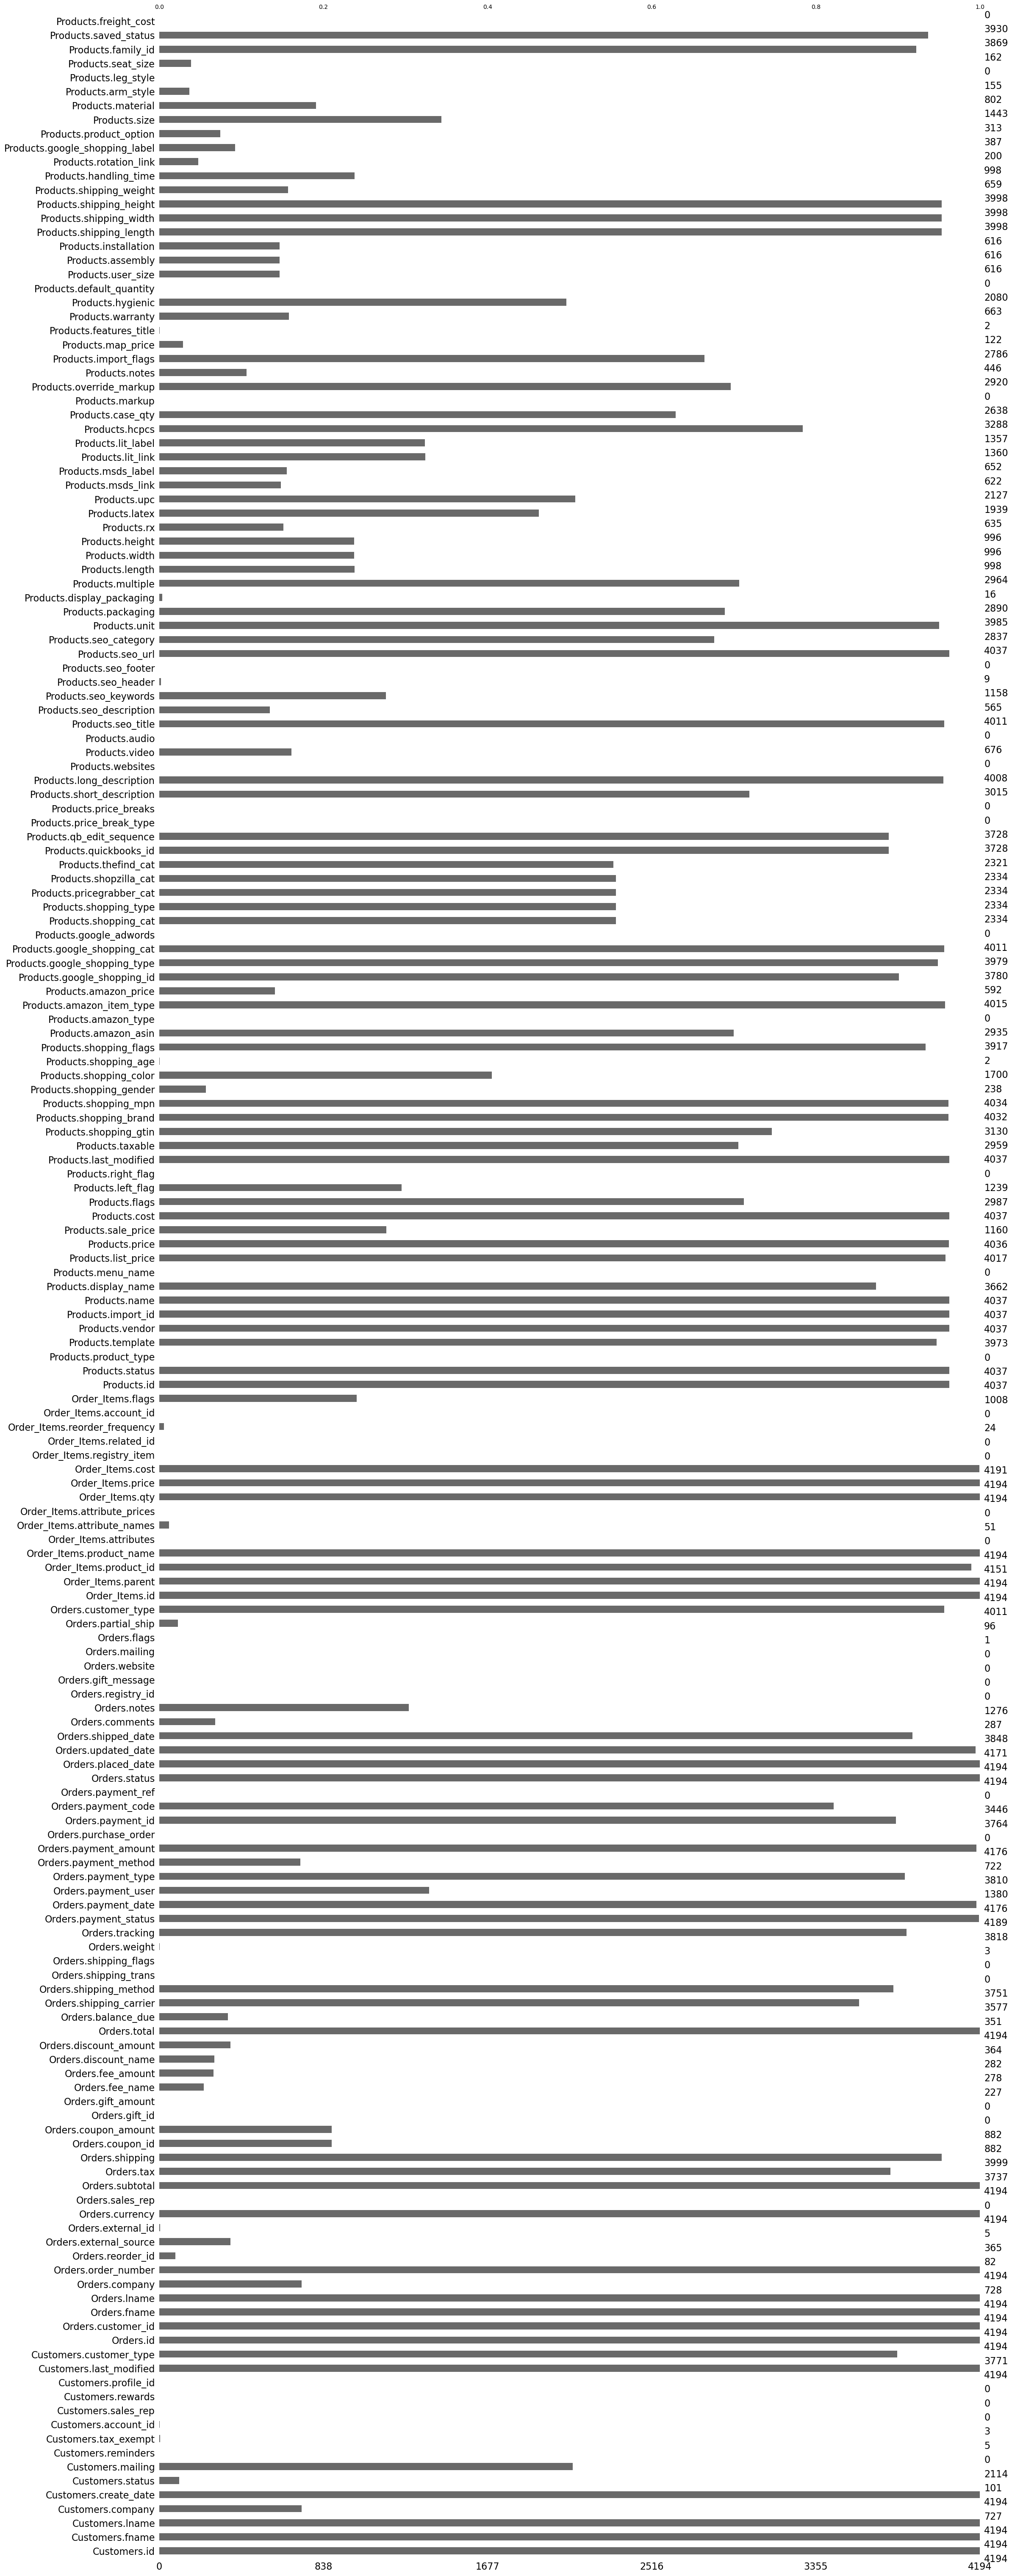

In [9]:
# Eksik verileri görselleştirme (bar grafiği)
msng.bar(df);  
# Her kolon için eksik veri miktarını çubuk grafik ile gösterir

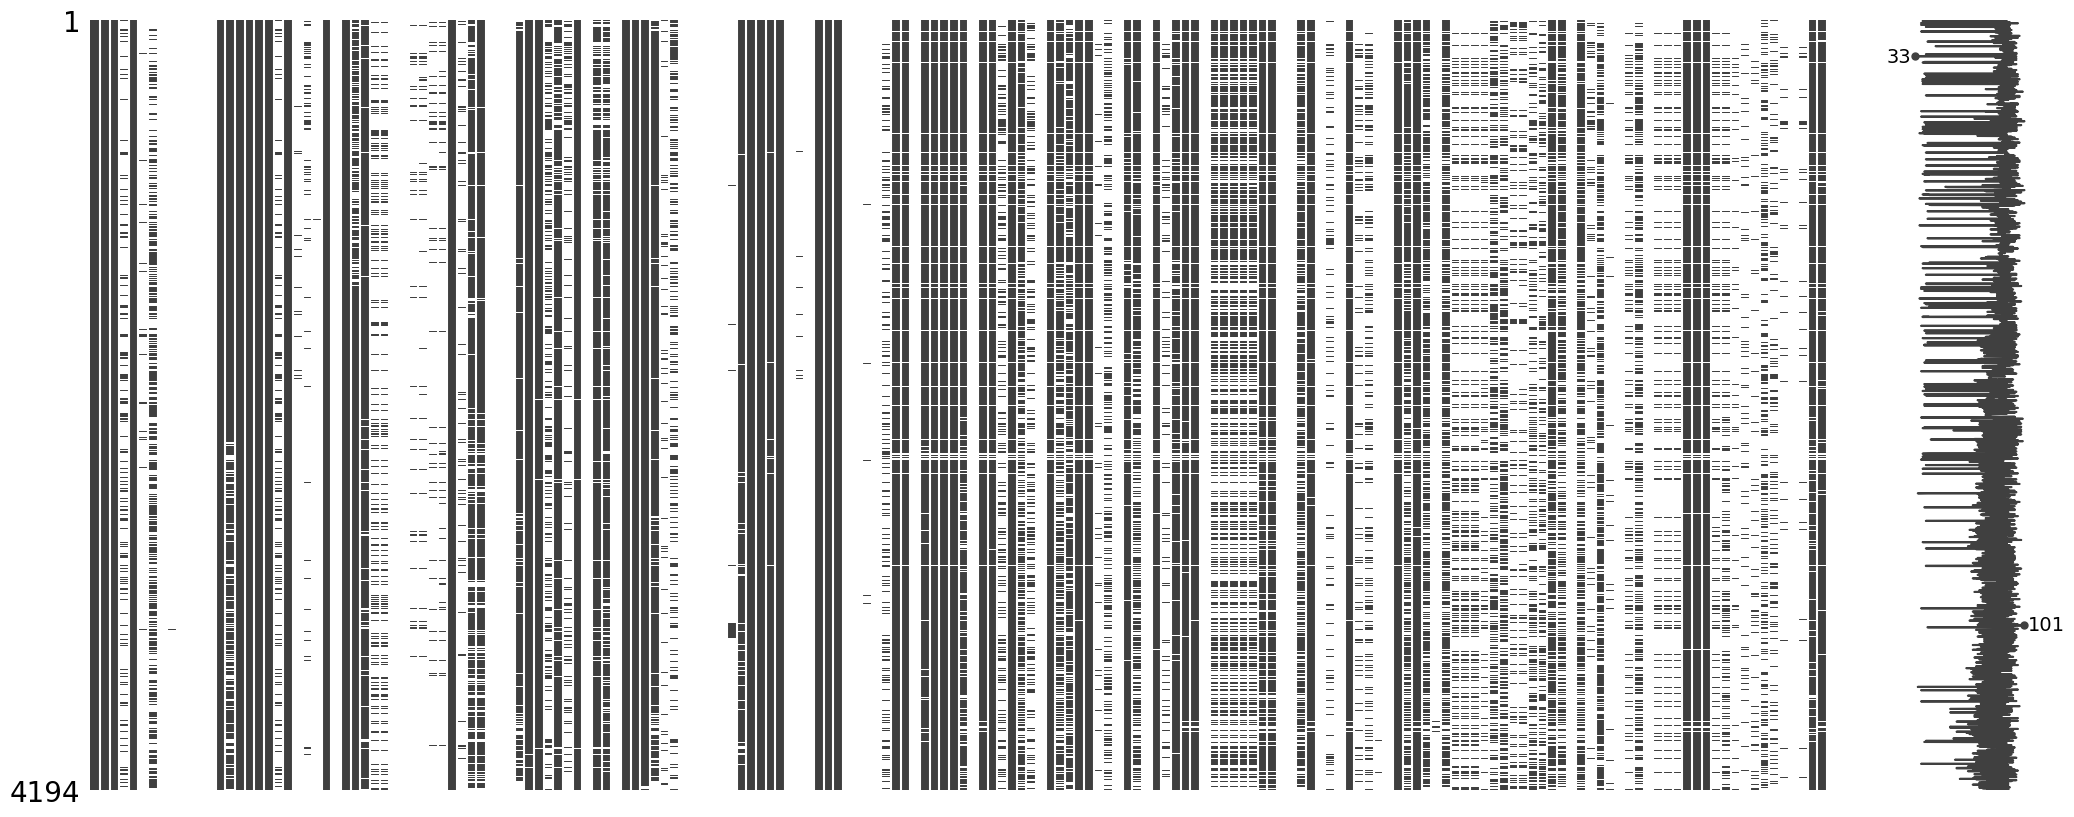

In [11]:
# Eksik verilerin matriks şeklinde görselleştirilmesi
msng.matrix(df);  
# Hangi satır ve kolonlarda eksik veriler olduğunu görsel olarak gösterir

### _Missing Data_

In [13]:
# %50’den fazla eksik veri olan kolonları kaldır
df = df.loc[:, df.isnull().mean() < 0.5]

In [14]:
# Kategorik kolonlardaki eksikleri 'Unknown' ile doldur
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').fillna('Unknown')

In [16]:
# Sayısal kolonları seç
num_cols = df.select_dtypes(include=['number']).columns

In [17]:
# Eksikleri ortalama ile doldur
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [18]:
df.isnull().sum()  # kontrol

Customers.id                     0
Customers.fname                  0
Customers.lname                  0
Customers.create_date            0
Customers.mailing                0
Customers.last_modified          0
Customers.customer_type          0
Orders.id                        0
Orders.customer_id               0
Orders.fname                     0
Orders.lname                     0
Orders.order_number              0
Orders.currency                  0
Orders.subtotal                  0
Orders.tax                       0
Orders.shipping                  0
Orders.total                     0
Orders.shipping_carrier          0
Orders.shipping_method           0
Orders.tracking                  0
Orders.payment_status            0
Orders.payment_date              0
Orders.payment_type              0
Orders.payment_amount            0
Orders.payment_id                0
Orders.payment_code              0
Orders.status                    0
Orders.placed_date               0
Orders.updated_date 

In [19]:
# Gereksiz sütunları belirle
columns_to_drop = [
    # Orders tablosu
    'Orders.fname', 'Orders.lname', 'Orders.payment_amount', 'Orders.payment_id',
    'Orders.payment_code', 'Orders.updated_date', 'Orders.shipping_carrier',
    'Orders.shipping_method', 'Orders.tracking', 'Orders.customer_type',

    # Order_Items tablosu
    'Order_Items.id', 'Order_Items.parent',

    # Products tablosu
    'Products.template', 'Products.vendor', 'Products.import_id', 'Products.display_name',
    'Products.flags', 'Products.last_modified', 'Products.taxable', 'Products.shopping_gtin',
    'Products.shopping_brand', 'Products.shopping_mpn', 'Products.shopping_flags',
    'Products.amazon_asin', 'Products.amazon_item_type', 'Products.google_shopping_id',
    'Products.google_shopping_type', 'Products.google_shopping_cat', 'Products.shopping_cat',
    'Products.shopping_type', 'Products.pricegrabber_cat', 'Products.shopzilla_cat',
    'Products.thefind_cat', 'Products.quickbooks_id', 'Products.qb_edit_sequence',
    'Products.short_description', 'Products.long_description', 'Products.seo_title',
    'Products.seo_url', 'Products.seo_category', 'Products.unit', 'Products.packaging',
    'Products.multiple', 'Products.upc', 'Products.hcpcs', 'Products.case_qty',
    'Products.override_markup', 'Products.import_flags', 'Products.shipping_length',
    'Products.shipping_width', 'Products.shipping_height', 'Products.family_id',
    'Products.saved_status'
]

In [20]:
# DataFrame'den sütunları sil
df = df.drop(columns=columns_to_drop)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customers.id              4194 non-null   int64  
 1   Customers.fname           4194 non-null   object 
 2   Customers.lname           4194 non-null   object 
 3   Customers.create_date     4194 non-null   int64  
 4   Customers.mailing         4194 non-null   float64
 5   Customers.last_modified   4194 non-null   int64  
 6   Customers.customer_type   4194 non-null   float64
 7   Orders.id                 4194 non-null   int64  
 8   Orders.customer_id        4194 non-null   int64  
 9   Orders.order_number       4194 non-null   object 
 10  Orders.currency           4194 non-null   object 
 11  Orders.subtotal           4194 non-null   float64
 12  Orders.tax                4194 non-null   float64
 13  Orders.shipping           4194 non-null   float64
 14  Orders.t

## _Most Popular Product_

In [23]:
def m_pop(column_name, ranking="total"):
    return (
        df.groupby(column_name)  # Belirtilen sütuna göre veriyi grupla
          .agg(
              total_qty=("Order_Items.qty", "sum"),   # Her grup için toplam adet
              mean_price=("Order_Items.price", "mean")  # Her grup için ortalama fiyat
          )
          .assign(
              total_amount=lambda x: x.total_qty * x.mean_price  # Toplam geliri hesapla
          )
          .nlargest(
              5, 
              'total_qty' if ranking == 'sum' else 'total_amount'  # ranking parametresine göre ilk 5'i al
          )
    )

### _Sales Ranking_

In [24]:
m_pop("Order_Items.product_name","sum")

,total_qty,mean_price,total_amount
Order_Items.product_name,,,
TruTemp,500,2.990000,1495.000000
"Disposable Emergency Blanket, Gray, Not Applicable",305,34.610000,10556.050000
"2-Ply Tissue/Poly Professional Towels, White, Not Applicable",220,25.270000,5559.400000
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size,164,54.760377,8980.701887
Sanitary Pads with Adhesive & Wings,133,42.320000,5628.560000


### _Total Amount Ranking by Porduct_

In [25]:
m_pop("Order_Items.product_name")

,total_qty,mean_price,total_amount
Order_Items.product_name,,,
"Disposable Emergency Blanket, Gray, Not Applicable",305,34.610000,10556.050000
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size,164,54.760377,8980.701887
"Medline Deluxe Aluminum Transport Chair With Hand Brakes, Red, Wheels Front 8"" Back 12"", Leightweight Weighs 23 Lbs, Cap. 300 Lbs.",47,126.620870,5951.180870
Sanitary Pads with Adhesive & Wings,133,42.320000,5628.560000
"2-Ply Tissue/Poly Professional Towels, White, Not Applicable",220,25.270000,5559.400000


### _The Most Popular Product_

In [28]:
m_pop("Order_Items.product_name","sum")

,total_qty,mean_price,total_amount
Order_Items.product_name,,,
TruTemp,500,2.990000,1495.000000
"Disposable Emergency Blanket, Gray, Not Applicable",305,34.610000,10556.050000
"2-Ply Tissue/Poly Professional Towels, White, Not Applicable",220,25.270000,5559.400000
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size,164,54.760377,8980.701887
Sanitary Pads with Adhesive & Wings,133,42.320000,5628.560000


### _The highest turnover by product_

In [29]:
m_pop("Order_Items.product_name","total")

,total_qty,mean_price,total_amount
Order_Items.product_name,,,
"Disposable Emergency Blanket, Gray, Not Applicable",305,34.610000,10556.050000
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size,164,54.760377,8980.701887
"Medline Deluxe Aluminum Transport Chair With Hand Brakes, Red, Wheels Front 8"" Back 12"", Leightweight Weighs 23 Lbs, Cap. 300 Lbs.",47,126.620870,5951.180870
Sanitary Pads with Adhesive & Wings,133,42.320000,5628.560000
"2-Ply Tissue/Poly Professional Towels, White, Not Applicable",220,25.270000,5559.400000


## _Build a recommender system using matrix factorization_

In [34]:
matrix = df.pivot_table(
    index="Orders.customer_id",       # Satırlarda müşteriler
    columns="Order_Items.product_name", # Sütunlarda ürünler
    values="Order_Items.qty"           # Hücrelerde satın alma miktarları
).fillna(0)                           # Eksik değerleri 0 ile doldur
matrix.head()

Order_Items.product_name,"BUCKET, REPLACEMENT FOR MDS89668XW",1 Box Of Medline Commode Liners with Absorbent Pad,1 Pad of CURAD Mediplast Wart Pad,"1-Ply Blockade AngelStat Surgical Gowns, Ceil Blue, Extra Large","1/2"" self-adhesive hook material, 25 yard dispenser box, white","1/2"" self-adhesive loop material, 25 yard dispenser box, white","100% Cotton Unisex Reversible Hyperbaric Scrub Tops, Misty Green, MZS","100% Cotton Unisex Reversible Tops, Ceil Blue, MHS",10215-s,12112-3,12124-3,"18"" Hamper Stands, Standard","19"" Flyweight Lightweight Blue Transport Wheelchair","2"" self-adhesive loop material, 10 yard dispenser box, tan","2"" self-adhesive loop material, 25 yard dispenser box, tan","2-Ply Tissue/Poly Professional Towels, White, Not Applicable",2000 Extra-Wide Wheelchairs,2000 Wheelchairs,"24 Hour Urine Collection Bottle, 3000.0 ML","3 Pack, Hospital Receiving Blankets, Baby Blankets, 100% Cotton, 30x40, Elephant","3 Pack, Hospital Receiving Blankets, Baby Blankets, 100% Cotton, 34x40, Footprints",3 Wheel Flame Blue Rollator Walker with Basket Tray and Pouch,3 Wheel Flame Red Rollator Walker with Basket Tray and Pouch,"3 Wheel Walker Rollator with Basket Tray and Pouch, Flame Blue","3 Wheel Walker Rollator with Basket Tray and Pouch, Flame Red","3"" Wheels For Walkers","3/4"" Guardian Utility Tips, Gray","4-Panel Abdominal Binders, 2X-Large","4-Panel Abdominal Binders, Large/X-Large","5"" Wheels For Walkers","6 Cylinder Oxygen Carrier, M9 Cylinders",6' CPAP Tube,6-spring hand grip (each),6291hda Universal wheels part,"8"" Rear Walker Wheel Attachment","A&D Ointment by H & H Laboratories Inc, 384.00 ML",Accu-Therm Hot/Cold Gel Packs,Accu-Therm Insulated Hot Pack,Accu-Therm Non-Insulated Hot Pack,"Accutouch Chemo Nitrile Exam Gloves, Blue, Medium","Active Liquid Protein Nutritional Supplement, 0.0","Active Liquid Protein Nutritional Supplement, 30.000 OZ",AcuForce&reg; 7.0 Massage Tool,Adaptive Eating Utensils - Adaptive Fork,Addipak Sterile Saline Solution,Adjustable Angle Rotating Suction Cup Grab Bar,Adjustable Height ArmRest AK5ADJARMKIT,Adjustable Height Bathtub Grab Bar Safety Rail,Adjustable Height Home Bed Assist Handle,"Adjustable Height Rollator with 6"" Wheels, Red","Adjustable Height Teak Bath Bench Stool, Rectangular","Adjustable Height Teak Bath Bench Stool, Triangular",Adjustable Height Triangular Teak Bath Bench Stool,"Adjustable Lightweight Folding Cane with Gel Hand Grip, Black","Adjustable Lightweight Folding Cane with Gel Hand Grip, Blue Crackle","Adjustable Lightweight Folding Cane with Gel Hand Grip, Red Crackle",Adult Bariatric Crutches,"AdvanTrode&reg; Elite Electrode, 2"" round, tan tricot, 40/box",Advantage Magnetic Patient Alarms,Advantage Select SE Mattresses,Advantage Therapeutic Homecare Foam Mattress,Aero-Pulse Pressure Pads,Aeroflow II Wheelchair Cushions,Aeroflow Static Air Overlay,Aeromist Plus Nebulizer Compressor with Disposable Nebulizer Kit,Airone Alternating Pressure Pads,All Weather Premium Quality Shopping Utility Bag - Green,"Aloetouch 3G Powder-Free Latex-Free Synthetic Exam Gloves, Large","Aloetouch 3G Powder-Free Latex-Free Synthetic Exam Gloves, Medium","Aloetouch 3G Powder-Free Latex-Free Synthetic Exam Gloves, Small","Aloetouch 3G Powder-Free Latex-Free Synthetic Exam Gloves, X-Large","Aloetouch Extended Cuff Chemo Nitrile Exam Gloves, Green, Medium","Aloetouch Extended Cuff Chemo Nitrile Exam Gloves, Green, Small","Aloetouch Extended Cuff Chemo Nitrile Exam Gloves, Green, X-Large",Aloetouch PROTECT Dimethicone Skin Protectant Wipes,Aloetouch Personal Cleansing Wipes,"Aloetouch Powder-Free Latex Exam Gloves, Green, X-Small",Aloetouch SELECT Premium Spunlace Personal Cleansing Wipes,Aloetouch Sensitive Personal Cleansing Baby Wipes,"Aloetouch Ultra IC Powder-Free Latex-Free Synthetic Exam Gloves, Large","Aloetouch Ultra IC Powder-Free Latex-Free Synthetic Exam Gloves, Medium",Aluminum Bath Benches with Back,Aluminum Folding Commode with Padded Armrests,"Aluminum Forearm 

In [55]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=20, random_state=42)  # Boyut indirgeme
matrix_svd = svd.fit_transform(matrix)

In [36]:
m_pop("Order_Items.product_name","sum")

,total_qty,mean_price,total_amount
Order_Items.product_name,,,
TruTemp,500,2.990000,1495.000000
"Disposable Emergency Blanket, Gray, Not Applicable",305,34.610000,10556.050000
"2-Ply Tissue/Poly Professional Towels, White, Not Applicable",220,25.270000,5559.400000
Medline MoliCare Super Plus Disposable Adult Diapers - Medium/Large Size,164,54.760377,8980.701887
Sanitary Pads with Adhesive & Wings,133,42.320000,5628.560000


In [38]:
# TruTemp ürün sütununu seç
product_TruTemp = matrix["TruTemp"]
product_TruTemp.head()

Orders.customer_id
3    0.0
4    0.0
5    0.0
7    0.0
8    0.0
Name: TruTemp, dtype: float64

In [39]:
# TruTemp sütunundaki farklı değer sayısını hesapla
product_TruTemp.nunique()

2

In [40]:
# TruTemp sütunundaki benzersiz (unique) değerleri listele
product_TruTemp.unique()

array([  0., 500.])

In [41]:
# TruTemp sütunundaki her bir değerin kaç kez tekrar ettiğini say
product_TruTemp.value_counts()

TruTemp
0.0      3053
500.0       1
Name: count, dtype: int64

In [42]:
# TruTemp ürünü ile "Disposable Emergency Blanket, Gray, Not Applicable" ürünü arasındaki korelasyonu hesapla
matrix[["TruTemp","Disposable Emergency Blanket, Gray, Not Applicable"]].corr()

Order_Items.product_name,TruTemp,"Disposable Emergency Blanket, Gray, Not Applicable"
Order_Items.product_name,,
TruTemp,1.000000,-0.000545
"Disposable Emergency Blanket, Gray, Not Applicable",-0.000545,1.000000


In [43]:
# TruTemp ürünü ile "2-Ply Tissue/Poly Professional Towels, White, Not Applicable" ürünü arasındaki korelasyonu hesapla
matrix[["TruTemp","2-Ply Tissue/Poly Professional Towels, White, Not Applicable"]].corr()

Order_Items.product_name,TruTemp,"2-Ply Tissue/Poly Professional Towels, White, Not Applicable"
Order_Items.product_name,,
TruTemp,1.000000,-0.000328
"2-Ply Tissue/Poly Professional Towels, White, Not Applicable",-0.000328,1.000000


In [44]:
# Boş bir DataFrame oluşturuyoruz; ileride TruTemp ile ilgili verileri buraya ekleyebiliriz
truTemp_df = pd.DataFrame()

In [45]:
# TruTemp ürünü ile diğer ürünler arasındaki korelasyonu hesaplayıp bir DataFrame'e ekliyoruz
truTemp_df["product"] = matrix.corrwith(product_TruTemp).index  # Ürün isimleri
truTemp_df["correlation"] = matrix.corrwith(product_TruTemp).values  # Korelasyon değerleri

# Korelasyon değerlerine göre azalan sırada sıralıyoruz
truTemp_df.sort_values("correlation", ascending=False)

,product,correlation
1675,TruTemp,1.000000
1197,"Phlebotomy Sharps Containers, Red, 1.000 QT",0.707028
1022,Medline MSC327100 Capri Bladder Control Pads,-0.000328
1260,"Protection Plus Classic Protective Underwear, ...",-0.000328
315,CanDo&reg; Latex Free Exercise Band - 50 yard ...,-0.000328
...,...,...
953,"Medline Emesis/Barf Bags, Blue - 24 Pack",-0.001561
1266,Protection Plus Disposable Underpads,-0.001577
838,K1 Basic Extra-Wide Wheelchairs,-0.001900
954,"Medline Emesis/Barf Bags, throw up bags, Blue ...",-0.002066


## _Cosine similarity for product description_

### _Build a recommendation system using matrix parsing_

#### _KNN_

In [46]:
# CountVectorizer ile ürün açıklamalarını sayısal forma çeviriyoruz
from sklearn.feature_extraction.text import CountVectorizer

# Bir metin listesi (ör. ürün açıklamaları) kullanıyoruz
vect = CountVectorizer()  # Metinleri sayısal özelliklere dönüştürmek için
sparse_matrix = vect.fit_transform(df)  # df burada ürün açıklamalarını içeren bir seri veya liste olmalı

In [47]:
# Sparse matrix'i dense formata çeviriyoruz ve DataFrame haline getiriyoruz
doc_term_matrix = sparse_matrix.todense()  # Sparse matrix'i yoğun (dense) matrise çevir
df = pd.DataFrame(doc_term_matrix, columns=vect.get_feature_names_out())  
# Her sütun bir kelimeyi temsil eder

In [48]:
df

,cost,create_date,currency,customer_id,customer_type,customers,fname,id,last_modified,list_price,lname,mailing,name,order_items,order_number,orders,payment_date,payment_status,payment_type,placed_date,price,product_id,product_name,products,qty,shipped_date,shipping,status,subtotal,tax,total
0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
df.shape

(32, 31)

In [50]:
# Cosine similarity hesaplamak için gerekli kütüphane
from sklearn.metrics.pairwise import cosine_similarity

In [51]:
# Tüm ürün açıklamaları arasındaki cosine similarity değerlerini DataFrame olarak göstermek
cosine_sim_df = pd.DataFrame(cosine_similarity(df, df))
cosine_sim_df.head()  # İlk birkaç satırı görmek için

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
1,0.5,1.0,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.5,0.5,1.0,0.5,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.5,0.5,0.5,1.0,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.5,0.5,0.5,0.5,1.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
user_sim = cosine_similarity(matrix_svd)
user_sim_df = pd.DataFrame(user_sim, index=matrix.index, columns=matrix.index)

In [57]:
user_id = 3
top_users = user_sim_df[user_id].sort_values(ascending=False)[1:6]  # kendisi hariç
print("User-based Benzer Kullanıcılar:\n", top_users)

User-based Benzer Kullanıcılar:
 Orders.customer_id
2638    0.996124
2463    0.995827
2242    0.995827
2101    0.995827
1502    0.995827
Name: 3, dtype: float64


In [58]:
product_sim = cosine_similarity(matrix.T)
product_sim_df = pd.DataFrame(product_sim, index=matrix.columns, columns=matrix.columns)

In [60]:
top_products = product_sim_df["TruTemp"].sort_values(ascending=False)[1:6]
print("\nTruTemp Ürününe Benzer Ürünler:\n", top_products)


TruTemp Ürününe Benzer Ürünler:
 Order_Items.product_name
Phlebotomy Sharps Containers, Red, 1.000 QT                                           0.707107
2000 Wheelchairs                                                                      0.000000
24 Hour Urine Collection Bottle, 3000.0 ML                                            0.000000
3 Pack, Hospital Receiving Blankets, Baby Blankets, 100% Cotton, 30x40, Elephant      0.000000
3 Pack, Hospital Receiving Blankets, Baby Blankets, 100% Cotton, 34x40, Footprints    0.000000
Name: TruTemp, dtype: float64


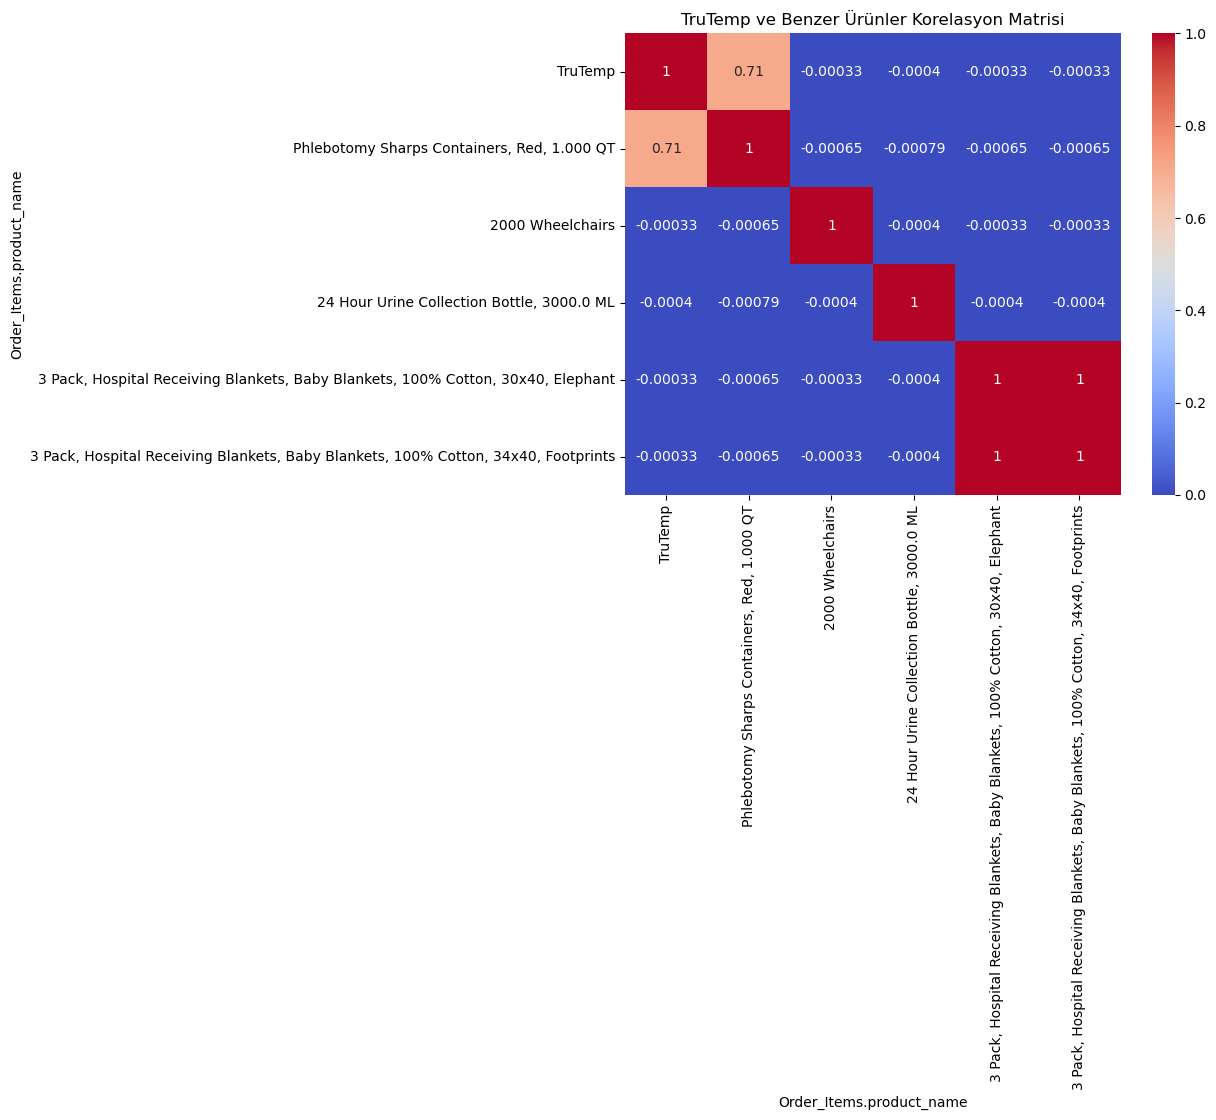

In [62]:
top_corr_products = product_sim_df["TruTemp"].sort_values(ascending=False).head(6).index
plt.figure(figsize=(8,6))
sns.heatmap(matrix[top_corr_products].corr(), annot=True, cmap="coolwarm")
plt.title("TruTemp ve Benzer Ürünler Korelasyon Matrisi")
plt.show()

## _Satış Öneri Sistemi Projesi – Sonuç Raporu_

**_Projenin Amacı_**
_Şirketin satışlarını artırmak ve müşteri davranışlarını analiz ederek öneri sistemleri geliştirmek._ <br>

**_Yaptıklarım_** <br>
_1. **Veri Hazırlığı**_ <br>
   _- Eksik verileri kontrol ettim, gerekli tüm sütunları kullandım._ <br>
   _- Müşteri, sipariş ve ürün bilgilerini analiz için hazır hale getirdim._ <br>

_2. **Popüler Ürün Analizi**_ <br>
  _- Ürünleri hem **satış adedi** hem de **toplam tutar** üzerinden sıraladım._ <br>
   _- En çok satılan ürünleri ve gelir getiren ürünleri belirledim._ <br>

_3. **En Çok Satın Alma Yapan Şirketler**_ <br>
   _- Şirketleri **satın alma adedi** ve **tutar** üzerinden sıraladım._ <br>
   _- En yüksek satış hacmine sahip müşterileri tespit ettim._ <br>

_4. **Popülerlik Tabanlı Öneri Sistemi**_ <br>
   _- Satış hacmine ve tutara göre ürün önerileri oluşturuldu._ <br>

_5. **Matris Çarpanlarına Dayalı Öneri Sistemi**_ <br>
   _- Müşteri-ürün pivot tablosu oluşturdum._ <br>
   _- Matris çarpanları ve korelasyon analizleri ile ürün önerileri belirledim._ <br>

_6. **Ürün Açıklamasına Dayalı Cosine Benzerliği**_ <br>
  _- Ürün açıklamalarını sayısal vektörlere dönüştürdüm._ <br>
   _- Cosine similarity kullanarak ürünler arası benzerlik hesapladım ve öneri sistemi kurdum._ <br>

**_Sonuç_** <br>
_- Veri eksikliği yoktu, veri hazırlığı tamamlandı._ <br>
_- Ürün ve müşteri analizleri ile popülerlik tabanlı öneri sistemi hazırlandı._ <br>
_- Matris çarpanı ve açıklama benzerliği tabanlı sistemler ile farklı öneri modelleri  uygulanabildi._ <br>
_- Bu çalışmalar, şirketin satış stratejilerini geliştirmek için kullanılabilir._ <br>